# EDA — Home Credit Default Risk: `installments_payments.csv`

## Purpose of this notebook

This is the most granular table in the dataset: **one row per installment**
of every previous loan (`SK_ID_PREV`), which itself belongs to a client
(`SK_ID_CURR`). Expect this table to have tens of millions of rows.

This is where genuinely behavioral, temporal signal lives — not "does this
client have debt" but "how does this client actually behave when a payment
is due, repeatedly, over time":

- `DAYS_INSTALMENT`: when the installment was supposed to be paid
- `DAYS_ENTRY_PAYMENT`: when it was actually paid
- `AMT_INSTALMENT`: how much was due
- `AMT_PAYMENT`: how much was actually paid

From these four columns we can derive **payment timeliness** (paid late? by
how many days?) and **payment completeness** (paid in full? underpaid?) —
at the level of individual installments, then aggregated per client.

1. Load the table, check shape/types (expect this to be slow — largest table so far)
2. One-to-many relationship with `SK_ID_CURR` (explicit merge check, not raw subtraction — lesson from `previous_application.csv`)
3. Missing values
4. Derive lateness and shortfall at the installment level
5. Early signal check: aggregate per client and merge with the target


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")

installments = pd.read_csv("../data/raw/home_credit/installments_payments.csv")
print(f"Shape: {installments.shape[0]:,} rows x {installments.shape[1]} columns")
installments.head()

Shape: 13,605,401 rows x 8 columns


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


## 1. Data types and general shape

In [9]:
installments.info(verbose=False)
print()
print(installments.dtypes.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13605401 entries, 0 to 13605400
Columns: 8 entries, SK_ID_PREV to AMT_PAYMENT
dtypes: float64(5), int64(3)
memory usage: 830.4 MB

float64    5
int64      3
Name: count, dtype: int64


## 2. One-to-many relationship with `SK_ID_CURR`

Using an explicit merge/`isin` check against `application_train`, not a raw
subtraction — this table almost certainly also includes `application_test`
clients, same as `previous_application.csv`.

In [10]:
app_train = pd.read_csv("../data/raw/home_credit/application_train.csv", usecols=["SK_ID_CURR", "TARGET"])
n_total_clients = app_train["SK_ID_CURR"].nunique()

clients_in_train_with_installments = app_train["SK_ID_CURR"].isin(installments["SK_ID_CURR"]).sum()
n_clients_with_no_installments = n_total_clients - clients_in_train_with_installments

print(f"Total installment rows: {len(installments):,}")
print(f"application_train clients WITH at least one installment record: {clients_in_train_with_installments:,}")
print(f"application_train clients with NO installment record at all: {n_clients_with_no_installments:,} "
      f"({n_clients_with_no_installments / n_total_clients:.1%})")

records_per_client = installments.groupby("SK_ID_CURR").size()
print()
print("Distribution of installment rows per client (clients WITH at least 1):")
print(records_per_client.describe())

Total installment rows: 13,605,401
application_train clients WITH at least one installment record: 291,643
application_train clients with NO installment record at all: 15,868 (5.2%)

Distribution of installment rows per client (clients WITH at least 1):
count    339587.000000
mean         40.064552
std          41.053343
min           1.000000
25%          12.000000
50%          25.000000
75%          51.000000
max         372.000000
dtype: float64


## 3. Missing values

In [11]:
missing = installments.isna().sum()
missing_pct = (missing / len(installments) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
print(missing_pct)
print()
print("Note: missing DAYS_ENTRY_PAYMENT / AMT_PAYMENT likely means the "
      "installment was never actually paid — worth checking directly.")

never_paid = installments["AMT_PAYMENT"].isna().sum()
print(f"\nInstallments with AMT_PAYMENT missing (possibly never paid): {never_paid:,} "
      f"({never_paid / len(installments):.2%})")

DAYS_ENTRY_PAYMENT    0.021352
AMT_PAYMENT           0.021352
dtype: float64

Note: missing DAYS_ENTRY_PAYMENT / AMT_PAYMENT likely means the installment was never actually paid — worth checking directly.

Installments with AMT_PAYMENT missing (possibly never paid): 2,905 (0.02%)


## 4. Deriving lateness and shortfall at the installment level

- `DAYS_LATE = DAYS_ENTRY_PAYMENT - DAYS_INSTALMENT` — positive means paid
  after it was due (late), negative means paid early.
- `AMT_SHORTFALL = AMT_INSTALMENT - AMT_PAYMENT` — positive means the client
  paid less than what was due that installment.

Both are computed only on rows where a payment was actually recorded.

Share of installments paid LATE (any amount of days): 8.4%
Share of installments UNDERPAID (any amount): 9.5%


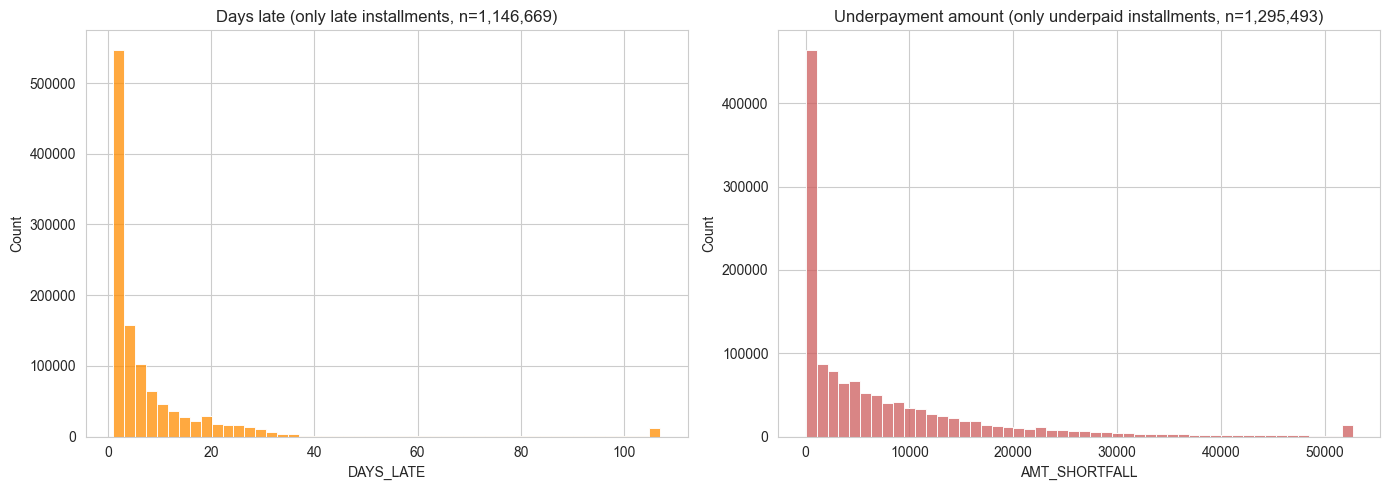

In [12]:
paid = installments.dropna(subset=["DAYS_ENTRY_PAYMENT", "AMT_PAYMENT"]).copy()
paid["DAYS_LATE"] = paid["DAYS_ENTRY_PAYMENT"] - paid["DAYS_INSTALMENT"]
paid["AMT_SHORTFALL"] = paid["AMT_INSTALMENT"] - paid["AMT_PAYMENT"]

pct_late = (paid["DAYS_LATE"] > 0).mean()
pct_underpaid = (paid["AMT_SHORTFALL"] > 0).mean()
print(f"Share of installments paid LATE (any amount of days): {pct_late:.1%}")
print(f"Share of installments UNDERPAID (any amount): {pct_underpaid:.1%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

late_only = paid.loc[paid["DAYS_LATE"] > 0, "DAYS_LATE"]
sns.histplot(late_only.clip(upper=late_only.quantile(0.99)), bins=50, ax=axes[0], color="darkorange")
axes[0].set_title(f"Days late (only late installments, n={len(late_only):,})")

shortfall_only = paid.loc[paid["AMT_SHORTFALL"] > 0, "AMT_SHORTFALL"]
sns.histplot(shortfall_only.clip(upper=shortfall_only.quantile(0.99)), bins=50, ax=axes[1], color="indianred")
axes[1].set_title(f"Underpayment amount (only underpaid installments, n={len(shortfall_only):,})")

plt.tight_layout()
plt.show()

## 5. Early signal check: does payment behavior correlate with the target?

This is the core hypothesis of the whole v2 migration: does actual,
granular payment behavior over time predict default better than static
snapshots did in v1. Aggregating per client:

- `PCT_INSTALLMENTS_LATE`: share of this client's installments paid late
- `AVG_DAYS_LATE`: average lateness (only counting late ones)
- `MAX_DAYS_LATE`: worst single lateness on record
- `EVER_SEVERELY_LATE`: flag for being 30+ days late at least once
- `PCT_INSTALLMENTS_UNDERPAID`: share of installments paid short

In [13]:
client_payment_behavior = paid.groupby("SK_ID_CURR").apply(
    lambda g: pd.Series({
        "PCT_INSTALLMENTS_LATE": (g["DAYS_LATE"] > 0).mean(),
        "AVG_DAYS_LATE": g.loc[g["DAYS_LATE"] > 0, "DAYS_LATE"].mean() if (g["DAYS_LATE"] > 0).any() else 0,
        "MAX_DAYS_LATE": g["DAYS_LATE"].max(),
        "EVER_SEVERELY_LATE": int((g["DAYS_LATE"] >= 30).any()),
        "PCT_INSTALLMENTS_UNDERPAID": (g["AMT_SHORTFALL"] > 0).mean(),
    }),
    include_groups=False
).reset_index()

merged = app_train.merge(client_payment_behavior, on="SK_ID_CURR", how="left")

print("Default rate by EVER_SEVERELY_LATE (0 = never 30+ days late, 1 = at least once):")
print(merged.groupby("EVER_SEVERELY_LATE")["TARGET"].agg(["mean", "count"]))

Default rate by EVER_SEVERELY_LATE (0 = never 30+ days late, 1 = at least once):
                        mean   count
EVER_SEVERELY_LATE                  
0.0                 0.080043  270693
1.0                 0.105434   20942


Default rate by bucket of PCT_INSTALLMENTS_LATE (low to high):
                      mean   count
LATE_RATE_BUCKET                  
(-0.001, 0.0486]  0.068263  174985
(0.0486, 0.143]   0.091484   59136
(0.143, 1.0]      0.113364   57514


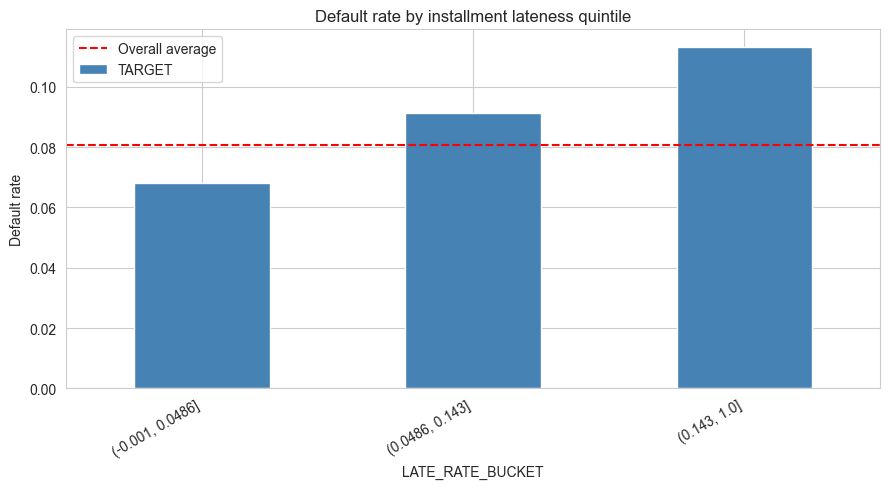

In [14]:
# Bucket PCT_INSTALLMENTS_LATE into quartiles to see if the RATE of
# lateness (not just ever/never) has a dose-response relationship with risk
merged_valid = merged.dropna(subset=["PCT_INSTALLMENTS_LATE"]).copy()
merged_valid["LATE_RATE_BUCKET"] = pd.qcut(
    merged_valid["PCT_INSTALLMENTS_LATE"], q=5, duplicates="drop"
)

print("Default rate by bucket of PCT_INSTALLMENTS_LATE (low to high):")
print(merged_valid.groupby("LATE_RATE_BUCKET", observed=True)["TARGET"].agg(["mean", "count"]))

plt.figure(figsize=(9, 5))
rate_by_bucket = merged_valid.groupby("LATE_RATE_BUCKET", observed=True)["TARGET"].mean()
rate_by_bucket.plot(kind="bar", color="steelblue")
plt.axhline(merged["TARGET"].mean(), color="red", linestyle="--", label="Overall average")
plt.title("Default rate by installment lateness quintile")
plt.ylabel("Default rate")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Investigating the spike near 100+ days late

Before finalizing conclusions, the DAYS_LATE histogram showed a small but
distinct spike far to the right (~100+ days), separate from the main
right-skewed cluster near zero. Given how often "weird spikes = a
placeholder or a real, meaningful subgroup" has turned out to be true
elsewhere in this project (`DAYS_EMPLOYED`'s 365243 placeholder, the
negative `BILL_AMT` values in v1), this is worth checking directly rather
than assuming it's noise.

In [15]:
# Zoom into the tail: what does the distribution actually look like above 60 days?
severe_late = paid.loc[paid["DAYS_LATE"] >= 60, "DAYS_LATE"]
print(f"Installments 60+ days late: {len(severe_late):,} ({len(severe_late) / len(paid):.3%} of all paid installments)")
print()
print("Value counts in the 90-120 day range (checking for a clustered/placeholder-like spike):")
print(severe_late[(severe_late >= 90) & (severe_late <= 120)].value_counts().sort_index())

Installments 60+ days late: 16,352 (0.120% of all paid installments)

Value counts in the 90-120 day range (checking for a clustered/placeholder-like spike):
DAYS_LATE
90.0      82
91.0     105
92.0      94
93.0      79
94.0      70
95.0      75
96.0      72
97.0      64
98.0      86
99.0      90
100.0     85
101.0     82
102.0     88
103.0     80
104.0     85
105.0     52
106.0     47
107.0     52
108.0     46
109.0     38
110.0     53
111.0     47
112.0     43
113.0     54
114.0     46
115.0     44
116.0     51
117.0     51
118.0     42
119.0     68
120.0     47
Name: count, dtype: int64


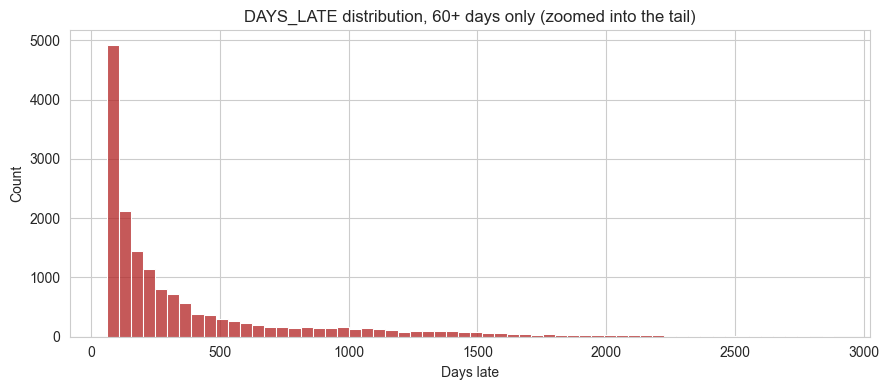

In [16]:
plt.figure(figsize=(9, 4))
sns.histplot(severe_late, bins=60, color="firebrick")
plt.title("DAYS_LATE distribution, 60+ days only (zoomed into the tail)")
plt.xlabel("Days late")
plt.tight_layout()
plt.show()

## 7. Summary and next steps

- 94.8% of application_train clients (291,643 of 307,511) have installment records; 5.2% have none.
- Clients with history have a median of 25 installments, mean 40 — much more granular than any prior table.
- Only 0.02% of installments have a missing payment (2,905 rows) — consistent with "genuinely never paid," handled by dropping before computing lateness/shortfall.
- **Strongest signal found so far in v2**: a clear dose-response relationship between installment lateness rate and default risk — 6.83% (rarely late) → 9.15% (moderately late) → 11.34% (frequently late), a 66% relative increase from lowest to highest tercile.
- Investigated an apparent spike near 100+ days in the DAYS_LATE tail: confirmed it's a genuine, smoothly-decaying long tail (16,352 installments, 0.12%, are 60+ days late), not a placeholder or data artifact — no fix needed.

**Conclusion:** `installments_payments.csv` provides the clearest behavioral signal of any table explored so far, validating the core premise of the v2 migration — granular, time-based payment behavior predicts risk more clearly than static snapshots or simple historical counts.

**Next:** `credit_card_balance.csv` — monthly credit card balance snapshots, the last of the five tables, which can add revolving-credit-specific behavioral patterns (utilization over time, minimum payments, drawing behavior) to complement the installment-level view.
